In [7]:
import requests
import pandas as pd
from google.colab import userdata

# Secret ka NAME yahan dena hai
API_KEY = userdata.get("MASSIVE_API_KEY")

if not API_KEY:
    raise ValueError("MASSIVE_API_KEY Colab Secrets mein set nahi hai.")

print("API Key loaded successfully!")

API Key loaded successfully!


In [15]:
import requests
import pandas as pd
import time

API_KEY = userdata.get("MASSIVE_API_KEY")

ticker = "AAPL"

all_data = []

# Multiple yearly ranges
date_ranges = [
    ("2020-01-01", "2021-01-01"),
    ("2021-01-01", "2022-01-01"),
    ("2022-01-01", "2023-01-01"),
    ("2023-01-01", "2024-01-01"),
    ("2024-01-01", "2025-01-01"),
    ("2025-01-01", "2026-01-01"),
    ("2026-01-01", "2026-08-01")
]

for start_date, end_date in date_ranges:

    print(f"\nFetching: {start_date} → {end_date}")

    url = f"https://api.massive.com/v2/aggs/ticker/{ticker}/range/1/minute/{start_date}/{end_date}"

    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 50000,
        "apiKey": API_KEY
    }

    response = requests.get(url, params=params)

    print("Status:", response.status_code)

    if response.status_code == 200:

        result = response.json()

        if "results" in result:
            batch = result["results"]

            print("Rows received:", len(batch))

            all_data.extend(batch)

        else:
            print("No results:", result)

    else:
        print("Error:", response.text)

    time.sleep(1)


# Convert to DataFrame
df_50k = pd.DataFrame(all_data)

print("\n" + "="*60)
print("FINAL DATASET")
print("="*60)

print("Total rows:", len(df_50k))
print("Total columns:", len(df_50k.columns))

display(df_50k.head())


Fetching: 2020-01-01 → 2021-01-01
Status: 403
Error: {"status":"NOT_AUTHORIZED","request_id":"ea92c16a153a0313e34892d4c6702114","message":"Your plan doesn't include this data timeframe. Please upgrade your plan at https://polygon.io/pricing"}

Fetching: 2021-01-01 → 2022-01-01
Status: 403
Error: {"status":"NOT_AUTHORIZED","request_id":"8a5aecd037ebe3e478a28e76866dd996","message":"Your plan doesn't include this data timeframe. Please upgrade your plan at https://polygon.io/pricing"}

Fetching: 2022-01-01 → 2023-01-01
Status: 403
Error: {"status":"NOT_AUTHORIZED","request_id":"eb562bc46f1329abd7d6a9a3f724c354","message":"Your plan doesn't include this data timeframe. Please upgrade your plan at https://polygon.io/pricing"}

Fetching: 2023-01-01 → 2024-01-01
Status: 403
Error: {"status":"NOT_AUTHORIZED","request_id":"0a292e93f5aa88f82ac687af487e5b27","message":"Your plan doesn't include this data timeframe. Please upgrade your plan at https://polygon.io/pricing"}

Fetching: 2024-01-01 → 

,v,vw,o,c,h,l,t,n
0,3475.0,216.7371,216.77,216.50,217.01,216.50,1723449600000,187
1,3853.0,216.3970,216.40,216.42,216.42,216.38,1723449660000,142
2,798.0,216.5768,216.69,216.69,216.69,216.69,1723449720000,103
3,2614.0,216.4048,216.50,216.30,216.50,216.30,1723449780000,124
4,3278.0,216.8553,216.82,216.90,216.96,216.82,1723449900000,100


In [16]:
df_50k = df_50k.rename(columns={
    "o": "open",
    "h": "high",
    "l": "low",
    "c": "close",
    "v": "volume",
    "vw": "vwap",
    "t": "timestamp",
    "n": "transactions"
})

df_50k["date"] = pd.to_datetime(
    df_50k["timestamp"],
    unit="ms"
)

df_50k = df_50k.sort_values("timestamp")
df_50k = df_50k.drop_duplicates(subset=["timestamp"])

# Exactly 50,000 rows
df_50k = df_50k.head(50000)

print("Final Shape:", df_50k.shape)
print("Start:", df_50k["date"].min())
print("End:", df_50k["date"].max())

Final Shape: (50000, 9)
Start: 2024-08-12 08:00:00
End: 2024-11-15 21:06:00


In [17]:
# Raw 50K dataset save karo
df_50k.to_csv(
    "AAPL_50000_raw.csv",
    index=False
)

print("Raw dataset saved!")
print("Shape:", df_50k.shape)

Raw dataset saved!
Shape: (50000, 9)


In [18]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

print("Shape:", df_50k.shape)

print("\nMissing Values:")
print(df_50k.isnull().sum())

print("\nDuplicate Timestamps:")
print(df_50k["timestamp"].duplicated().sum())

print("\nData Types:")
print(df_50k.dtypes)

print("\nFirst 5:")
display(df_50k.head())

print("\nLast 5:")
display(df_50k.tail())

DATA QUALITY CHECK
Shape: (50000, 9)

Missing Values:
volume          0
vwap            0
open            0
close           0
high            0
low             0
timestamp       0
transactions    0
date            0
dtype: int64

Duplicate Timestamps:
0

Data Types:
volume                 float64
vwap                   float64
open                   float64
close                  float64
high                   float64
low                    float64
timestamp                int64
transactions             int64
date            datetime64[ns]
dtype: object

First 5:


,volume,vwap,open,close,high,low,timestamp,transactions,date
0,3475.0,216.7371,216.77,216.50,217.01,216.50,1723449600000,187,2024-08-12 08:00:00
1,3853.0,216.3970,216.40,216.42,216.42,216.38,1723449660000,142,2024-08-12 08:01:00
2,798.0,216.5768,216.69,216.69,216.69,216.69,1723449720000,103,2024-08-12 08:02:00
3,2614.0,216.4048,216.50,216.30,216.50,216.30,1723449780000,124,2024-08-12 08:03:00
4,3278.0,216.8553,216.82,216.90,216.96,216.82,1723449900000,100,2024-08-12 08:05:00



Last 5:


,volume,vwap,open,close,high,low,timestamp,transactions,date
49995,2634.0,225.1370,225.10,225.0700,225.2000,225.07,1731704520000,62,2024-11-15 21:02:00
49996,22611.0,225.0113,225.10,225.2005,225.2005,225.00,1731704580000,31,2024-11-15 21:03:00
49997,3079.0,225.0701,225.05,225.0800,225.0800,225.05,1731704640000,43,2024-11-15 21:04:00
49998,1530.0,225.0847,225.05,225.0900,225.0900,225.05,1731704700000,35,2024-11-15 21:05:00
49999,1134.0,225.0761,225.09,225.0500,225.0900,225.05,1731704760000,21,2024-11-15 21:06:00


In [19]:
import numpy as np
import pandas as pd

# =========================================================
# 1. SORT DATA
# =========================================================

df = df_50k.copy()

df = df.sort_values("date").reset_index(drop=True)


# =========================================================
# 2. BASIC PRICE FEATURES
# =========================================================

df["return_1"] = df["close"].pct_change(1)

df["return_5"] = df["close"].pct_change(5)

df["return_10"] = df["close"].pct_change(10)

df["return_20"] = df["close"].pct_change(20)

df["log_return"] = np.log(
    df["close"] / df["close"].shift(1)
)


# =========================================================
# 3. CANDLE FEATURES
# =========================================================

df["body"] = df["close"] - df["open"]

df["body_abs"] = abs(df["body"])

df["upper_wick"] = (
    df["high"] -
    df[["open", "close"]].max(axis=1)
)

df["lower_wick"] = (
    df[["open", "close"]].min(axis=1) -
    df["low"]
)

df["candle_range"] = df["high"] - df["low"]

df["body_ratio"] = (
    df["body_abs"] /
    (df["candle_range"] + 1e-8)
)

df["close_position"] = (
    (df["close"] - df["low"]) /
    (df["candle_range"] + 1e-8)
)


# =========================================================
# 4. MOVING AVERAGES
# =========================================================

for window in [5, 10, 20, 50, 100]:

    df[f"MA_{window}"] = (
        df["close"]
        .rolling(window)
        .mean()
    )

    # Distance from moving average
    df[f"MA_distance_{window}"] = (
        df["close"] / df[f"MA_{window}"] - 1
    )


# =========================================================
# 5. EMA
# =========================================================

for window in [5, 10, 20, 50]:

    df[f"EMA_{window}"] = (
        df["close"]
        .ewm(span=window, adjust=False)
        .mean()
    )


# =========================================================
# 6. RSI
# =========================================================

delta = df["close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / (avg_loss + 1e-8)

df["RSI_14"] = 100 - (
    100 / (1 + rs)
)


# =========================================================
# 7. MACD
# =========================================================

ema_12 = (
    df["close"]
    .ewm(span=12, adjust=False)
    .mean()
)

ema_26 = (
    df["close"]
    .ewm(span=26, adjust=False)
    .mean()
)

df["MACD"] = ema_12 - ema_26

df["MACD_signal"] = (
    df["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)

df["MACD_hist"] = (
    df["MACD"] -
    df["MACD_signal"]
)


# =========================================================
# 8. BOLLINGER BANDS
# =========================================================

bb_mid = df["close"].rolling(20).mean()

bb_std = df["close"].rolling(20).std()

df["BB_middle"] = bb_mid

df["BB_upper"] = (
    bb_mid + 2 * bb_std
)

df["BB_lower"] = (
    bb_mid - 2 * bb_std
)

df["BB_width"] = (
    (df["BB_upper"] - df["BB_lower"]) /
    (df["BB_middle"] + 1e-8)
)

df["BB_position"] = (
    (df["close"] - df["BB_lower"]) /
    (
        df["BB_upper"] -
        df["BB_lower"] +
        1e-8
    )
)


# =========================================================
# 9. ATR
# =========================================================

prev_close = df["close"].shift(1)

tr1 = df["high"] - df["low"]

tr2 = abs(df["high"] - prev_close)

tr3 = abs(df["low"] - prev_close)

true_range = pd.concat(
    [tr1, tr2, tr3],
    axis=1
).max(axis=1)

df["ATR_14"] = (
    true_range
    .rolling(14)
    .mean()
)

df["ATR_percent"] = (
    df["ATR_14"] /
    df["close"]
)


# =========================================================
# 10. VOLATILITY
# =========================================================

for window in [5, 10, 20, 50]:

    df[f"volatility_{window}"] = (
        df["return_1"]
        .rolling(window)
        .std()
    )


# =========================================================
# 11. VOLUME FEATURES
# =========================================================

df["volume_change"] = (
    df["volume"].pct_change()
)

for window in [10, 20, 50]:

    df[f"volume_MA_{window}"] = (
        df["volume"]
        .rolling(window)
        .mean()
    )

    df[f"volume_ratio_{window}"] = (
        df["volume"] /
        (df[f"volume_MA_{window}"] + 1e-8)
    )


# =========================================================
# 12. VWAP FEATURES
# =========================================================

df["vwap_distance"] = (
    df["close"] / df["vwap"] - 1
)

df["open_vwap_distance"] = (
    df["open"] / df["vwap"] - 1
)


# =========================================================
# 13. PRICE POSITION FEATURES
# =========================================================

for window in [10, 20, 50]:

    rolling_high = (
        df["high"]
        .rolling(window)
        .max()
    )

    rolling_low = (
        df["low"]
        .rolling(window)
        .min()
    )

    df[f"high_distance_{window}"] = (
        df["close"] / rolling_high - 1
    )

    df[f"low_distance_{window}"] = (
        df["close"] / rolling_low - 1
    )


# =========================================================
# 14. TIME FEATURES
# =========================================================

df["hour"] = df["date"].dt.hour

df["minute"] = df["date"].dt.minute

df["day_of_week"] = df["date"].dt.dayofweek

# Cyclic encoding
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["minute_sin"] = np.sin(
    2 * np.pi * df["minute"] / 60
)

df["minute_cos"] = np.cos(
    2 * np.pi * df["minute"] / 60
)


# =========================================================
# 15. CLEAN
# =========================================================

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna().reset_index(drop=True)


# =========================================================
# FINAL CHECK
# =========================================================

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 60)

print("Original rows:", len(df_50k))

print("Final rows:", len(df))

print("Total columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nFeature columns:")
print(df.columns.tolist())

FEATURE ENGINEERING COMPLETE
Original rows: 50000
Final rows: 49901
Total columns: 72

Missing values:
0

Feature columns:
['volume', 'vwap', 'open', 'close', 'high', 'low', 'timestamp', 'transactions', 'date', 'return_1', 'return_5', 'return_10', 'return_20', 'log_return', 'body', 'body_abs', 'upper_wick', 'lower_wick', 'candle_range', 'body_ratio', 'close_position', 'MA_5', 'MA_distance_5', 'MA_10', 'MA_distance_10', 'MA_20', 'MA_distance_20', 'MA_50', 'MA_distance_50', 'MA_100', 'MA_distance_100', 'EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_middle', 'BB_upper', 'BB_lower', 'BB_width', 'BB_position', 'ATR_14', 'ATR_percent', 'volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'volume_change', 'volume_MA_10', 'volume_ratio_10', 'volume_MA_20', 'volume_ratio_20', 'volume_MA_50', 'volume_ratio_50', 'vwap_distance', 'open_vwap_distance', 'high_distance_10', 'low_distance_10', 'high_distance_20', 'low_distance_20', 'high_distance

In [20]:
# ==========================================
# STEP 1: CREATE TARGET
# ==========================================

# 5 minutes future return
df["future_return_5"] = (
    df["close"].shift(-5) / df["close"] - 1
)

# UP = 1
# DOWN = 0
df["target"] = (
    df["future_return_5"] > 0
).astype(int)

# Last 5 rows ka future available nahi hota
df = df.iloc[:-5].copy()

df = df.reset_index(drop=True)

print("=" * 60)
print("TARGET CREATED")
print("=" * 60)

print("Shape:", df.shape)

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(
    df["target"]
    .value_counts(normalize=True)
    .mul(100)
)

TARGET CREATED
Shape: (49896, 74)

Target Distribution:
target
0    25142
1    24754
Name: count, dtype: int64

Target Percentage:
target
0    50.388809
1    49.611191
Name: proportion, dtype: float64


In [21]:
# ==========================================
# CHECK TARGET
# ==========================================

display(
    df[
        [
            "date",
            "close",
            "future_return_5",
            "target"
        ]
    ].head(20)
)

,date,close,future_return_5,target
0,2024-08-12 12:00:00,216.7500,0.000046,1
1,2024-08-12 12:01:00,216.7810,0.000088,1
2,2024-08-12 12:03:00,216.7983,0.000008,1
3,2024-08-12 12:05:00,216.7900,-0.000092,0
4,2024-08-12 12:06:00,216.8000,0.000438,1
5,2024-08-12 12:07:00,216.7600,0.000646,1
6,2024-08-12 12:08:00,216.8000,0.000923,1
7,2024-08-12 12:09:00,216.8000,0.000461,1
8,2024-08-12 12:11:00,216.7700,0.000830,1
9,2024-08-12 12:16:00,216.8950,0.000484,1


In [22]:
# ==========================================
# STEP 3: CHRONOLOGICAL TRAIN/VAL/TEST SPLIT
# ==========================================

n = len(df)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()

val_df = df.iloc[train_end:val_end].copy()

test_df = df.iloc[val_end:].copy()


print("=" * 60)
print("DATA SPLIT")
print("=" * 60)

print("Total:", len(df))

print("\nTrain:")
print("Rows:", len(train_df))
print("Start:", train_df["date"].min())
print("End:", train_df["date"].max())

print("\nValidation:")
print("Rows:", len(val_df))
print("Start:", val_df["date"].min())
print("End:", val_df["date"].max())

print("\nTest:")
print("Rows:", len(test_df))
print("Start:", test_df["date"].min())
print("End:", test_df["date"].max())

DATA SPLIT
Total: 49896

Train:
Rows: 34927
Start: 2024-08-12 12:00:00
End: 2024-10-18 14:45:00

Validation:
Rows: 7484
Start: 2024-10-18 14:46:00
End: 2024-11-01 14:42:00

Test:
Rows: 7485
Start: 2024-11-01 14:43:00
End: 2024-11-15 21:01:00


In [23]:
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print("\nTRAIN:")
print(train_df["target"].value_counts())
print(train_df["target"].value_counts(normalize=True) * 100)

print("\nVALIDATION:")
print(val_df["target"].value_counts())
print(val_df["target"].value_counts(normalize=True) * 100)

print("\nTEST:")
print(test_df["target"].value_counts())
print(test_df["target"].value_counts(normalize=True) * 100)

TARGET DISTRIBUTION

TRAIN:
target
1    17571
0    17356
Name: count, dtype: int64
target
1    50.307785
0    49.692215
Name: proportion, dtype: float64

VALIDATION:
target
0    3915
1    3569
Name: count, dtype: int64
target
0    52.311598
1    47.688402
Name: proportion, dtype: float64

TEST:
target
0    3871
1    3614
Name: count, dtype: int64
target
0    51.716767
1    48.283233
Name: proportion, dtype: float64


In [24]:
# ==========================================
# STEP 4: SELECT FEATURES
# ==========================================

from sklearn.preprocessing import StandardScaler

# Ye columns model ko nahi dene
exclude_columns = [
    "date",
    "timestamp",
    "target",
    "future_return_5"
]

# Baqi columns features hain
feature_cols = [
    col for col in df.columns
    if col not in exclude_columns
]

print("Total Features:", len(feature_cols))

print("\nFeatures:")
print(feature_cols)

Total Features: 70

Features:
['volume', 'vwap', 'open', 'close', 'high', 'low', 'transactions', 'return_1', 'return_5', 'return_10', 'return_20', 'log_return', 'body', 'body_abs', 'upper_wick', 'lower_wick', 'candle_range', 'body_ratio', 'close_position', 'MA_5', 'MA_distance_5', 'MA_10', 'MA_distance_10', 'MA_20', 'MA_distance_20', 'MA_50', 'MA_distance_50', 'MA_100', 'MA_distance_100', 'EMA_5', 'EMA_10', 'EMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_middle', 'BB_upper', 'BB_lower', 'BB_width', 'BB_position', 'ATR_14', 'ATR_percent', 'volatility_5', 'volatility_10', 'volatility_20', 'volatility_50', 'volume_change', 'volume_MA_10', 'volume_ratio_10', 'volume_MA_20', 'volume_ratio_20', 'volume_MA_50', 'volume_ratio_50', 'vwap_distance', 'open_vwap_distance', 'high_distance_10', 'low_distance_10', 'high_distance_20', 'low_distance_20', 'high_distance_50', 'low_distance_50', 'hour', 'minute', 'day_of_week', 'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos']


In [25]:
# ==========================================
# STEP 5: SCALE FEATURES
# ==========================================

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df["target"]
y_val = val_df["target"]
y_test = test_df["target"]


# StandardScaler
scaler = StandardScaler()

# IMPORTANT:
# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Validation and Test par sirf transform
X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)


print("=" * 60)
print("SCALING COMPLETE")
print("=" * 60)

print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

SCALING COMPLETE
X_train: (34927, 70)
X_val: (7484, 70)
X_test: (7485, 70)
y_train: (34927,)
y_val: (7484,)
y_test: (7485,)


In [26]:
# ==========================================
# STEP 6: CREATE LSTM SEQUENCES
# ==========================================

import numpy as np

SEQUENCE_LENGTH = 60

def create_sequences(X, y, sequence_length=60):

    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(X)):
        X_seq.append(
            X[i-sequence_length:i]
        )

        y_seq.append(
            y.iloc[i]
        )

    return np.array(X_seq), np.array(y_seq)


# Create sequences
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    SEQUENCE_LENGTH
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val,
    SEQUENCE_LENGTH
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    SEQUENCE_LENGTH
)


print("=" * 60)
print("LSTM SEQUENCES")
print("=" * 60)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

LSTM SEQUENCES
X_train: (34867, 60, 70)
y_train: (34867,)
X_val: (7424, 60, 70)
y_val: (7424,)
X_test: (7425, 60, 70)
y_test: (7425,)


In [27]:
# ==========================================
# STEP 7: PYTORCH DATASET
# ==========================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# Convert NumPy → PyTorch tensors
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_seq,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_seq,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
)


# DataLoaders
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)


train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Device: cuda
Train: 34867
Validation: 7424
Test: 7425


In [28]:
# ==========================================
# STEP 8: LSTM MODEL
# ==========================================

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        input_size=70,
        hidden_size=128,
        num_layers=2,
        dropout=0.3
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc1 = nn.Linear(
            hidden_size,
            64
        )

        self.dropout = nn.Dropout(0.3)

        self.fc2 = nn.Linear(
            64,
            1
        )


    def forward(self, x):

        # x shape:
        # (batch, 60, 70)

        output, (hidden, cell) = self.lstm(x)

        # Last timestep
        x = output[:, -1, :]

        x = self.fc1(x)

        x = torch.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x.squeeze(1)

In [29]:
model = LSTMClassifier(
    input_size=70,
    hidden_size=128,
    num_layers=2,
    dropout=0.3
).to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(70, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [30]:
# ==========================================
# STEP 9: LOSS + OPTIMIZER
# ==========================================

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Model ready for training.")

Model ready for training.


In [31]:
# ==========================================
# STEP 10: TRAIN FUNCTION
# ==========================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item() *
            X_batch.size(0)
        )

        predictions = (
            torch.sigmoid(logits) >= 0.5
        ).float()

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_loss = total_loss / total

    accuracy = correct / total

    return avg_loss, accuracy

In [32]:
# ==========================================
# STEP 11: VALIDATION
# ==========================================

def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)

            loss = criterion(
                logits,
                y_batch
            )

            total_loss += (
                loss.item() *
                X_batch.size(0)
            )

            predictions = (
                torch.sigmoid(logits) >= 0.5
            ).float()

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    avg_loss = total_loss / total

    accuracy = correct / total

    return avg_loss, accuracy

In [33]:
# ==========================================
# STEP 12: TRAIN LSTM
# ==========================================

epochs = 30

best_val_loss = float("inf")

patience = 7

patience_counter = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_lstm_model.pth"
        )

        patience_counter = 0

        print("  ✓ Best model saved")

    else:

        patience_counter += 1


    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered.")

        break

Epoch [1/30] | Train Loss: 0.6943 | Train Acc: 0.5058 | Val Loss: 0.6930 | Val Acc: 0.5042
  ✓ Best model saved
Epoch [2/30] | Train Loss: 0.6932 | Train Acc: 0.5168 | Val Loss: 0.6944 | Val Acc: 0.4947
Epoch [3/30] | Train Loss: 0.6928 | Train Acc: 0.5160 | Val Loss: 0.6935 | Val Acc: 0.5003
Epoch [4/30] | Train Loss: 0.6923 | Train Acc: 0.5243 | Val Loss: 0.6933 | Val Acc: 0.4964
Epoch [5/30] | Train Loss: 0.6916 | Train Acc: 0.5299 | Val Loss: 0.6939 | Val Acc: 0.5032
Epoch [6/30] | Train Loss: 0.6892 | Train Acc: 0.5394 | Val Loss: 0.6941 | Val Acc: 0.5067
Epoch [7/30] | Train Loss: 0.6868 | Train Acc: 0.5465 | Val Loss: 0.6940 | Val Acc: 0.5136
Epoch [8/30] | Train Loss: 0.6832 | Train Acc: 0.5546 | Val Loss: 0.6949 | Val Acc: 0.5019

Early stopping triggered.


In [34]:
# ==========================================
# STEP 13: LOAD BEST MODEL
# ==========================================

model.load_state_dict(
    torch.load(
        "best_lstm_model.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


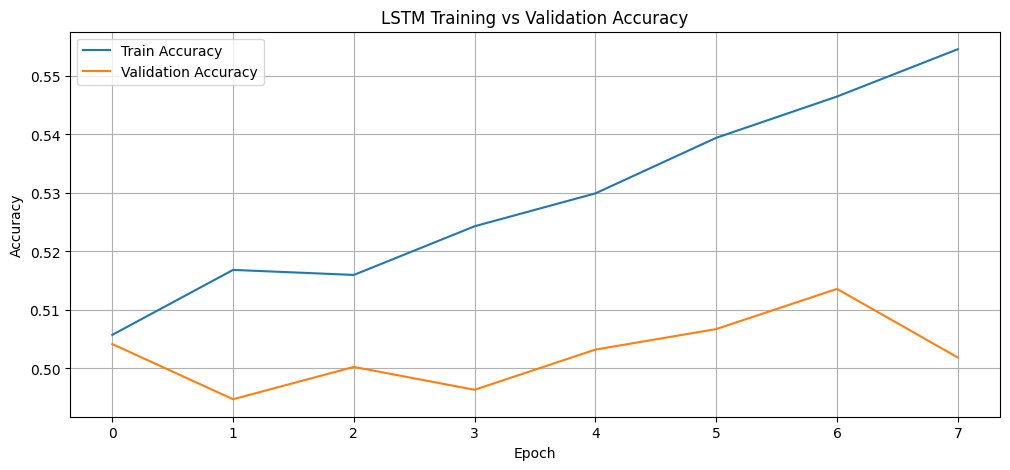

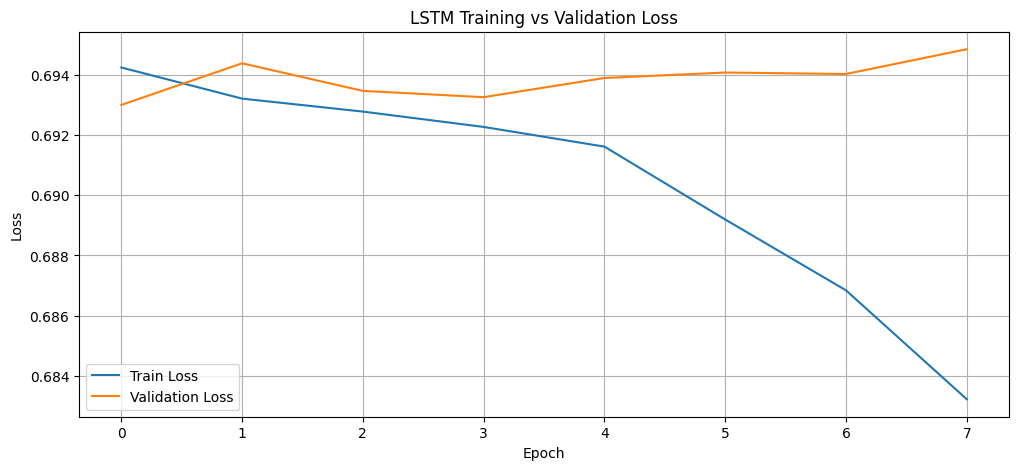

In [35]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12, 5))

plt.plot(
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# Loss
plt.figure(figsize=(12, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()